论文级 3D 矢量场 PDF 已成功导出！


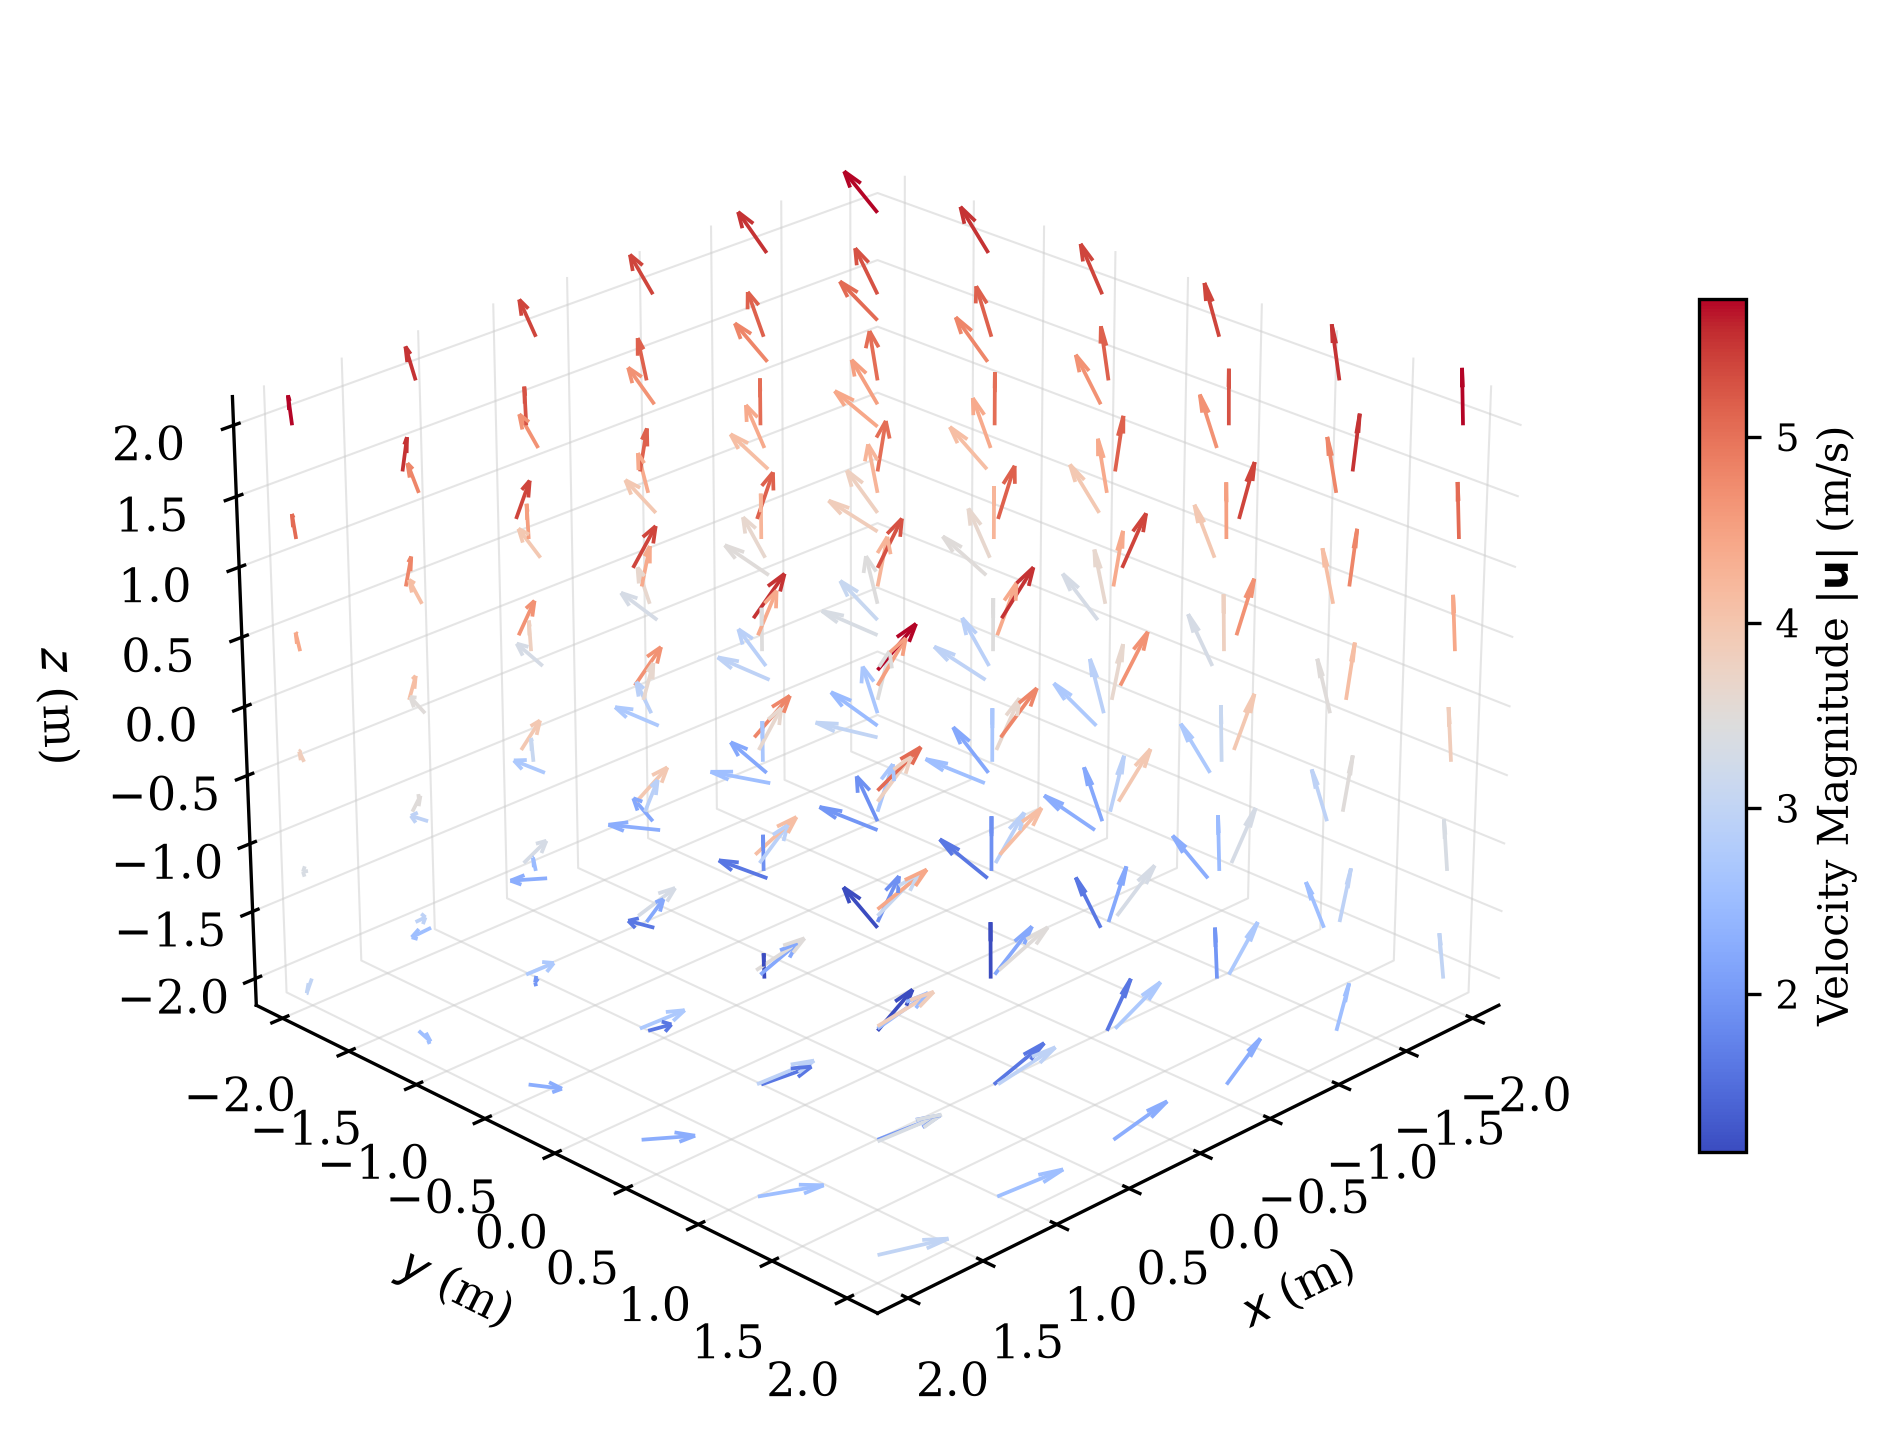

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 严格学术样式全局配置 (Academic Style Setup)
# ==========================================
plt.rcParams.update({
    "text.usetex": False,            # 如果电脑安装了系统级 LaTeX，可设为 True 开启完美数学公式
    "font.family": "serif",          # 选用衬线字体，贴合论文正文
    "font.size": 11,                 # 符合 IEEE 单栏或双栏图片的标准字号
    "axes.linewidth": 0.8,           # 坐标轴边框粗细
    "figure.dpi": 300                # 高清渲染
})

# ==========================================
# 2. 生成物理场数据 (等距 3D 点)
# ==========================================
# 严格控制采样率：8x8x8=512个点，在 3D 中可提供最清晰且不拥挤的视野
x = np.linspace(-2, 2, 6)
y = np.linspace(-2, 2, 6)
z = np.linspace(-2, 2, 6)
X, Y, Z = np.meshgrid(x, y, z)

# 物理方程定义：龙卷风模型 (水平气旋 + 立体发散上升)
U = -Y
V = X
W = Z + 3.0

# 计算标量流速 (Speed)，用于严格的色彩密度映射
speed = np.sqrt(U**2 + V**2 + W**2)

# ==========================================
# 3. 3D 画布高级精细化渲染
# ==========================================
fig = plt.figure(figsize=(6.5, 5.5))  # 设定严格的出版尺寸比例
ax = fig.add_subplot(111, projection='3d')

# 使用极为严谨的酷冷到炎热色彩梯度 (coolwarm)，并启用归一化箭头
# arrow_length_ratio 调节箭头箭尖的大小比例，使其显得精细、尖锐
q = ax.quiver(X, Y, Z, U, V, W, 
              length=0.35, 
              cmap='coolwarm', 
              array=speed.flatten(), 
              normalize=True,
              arrow_length_ratio=0.35,
              linewidths=0.9)

# 关键：彻底抹除默认的“塑料灰色”3D 背景面板，变成纯白高透风格
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# 调整网格线，使其变细、半透明，若完全不需要可直接使用 ax.grid(False)
ax.xaxis._axinfo["grid"]['linewidth'] = 0.5
ax.yaxis._axinfo["grid"]['linewidth'] = 0.5
ax.zaxis._axinfo["grid"]['linewidth'] = 0.5
ax.xaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
ax.yaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
ax.zaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)

# 使用数学语法书写标准的坐标轴 Label
ax.set_xlabel(r'$x$ (m)', labelpad=5)
ax.set_ylabel(r'$y$ (m)', labelpad=5)
ax.set_zlabel(r'$z$ (m)', labelpad=5)

# 设置严格的轴坐标显示边界
ax.set_xlim([-2.2, 2.2])
ax.set_ylim([-2.2, 2.2])
ax.set_zlim([-2.2, 2.2])

# 精准微调初始观察视角（elev为仰角，azim为方位角），这是展示 3D 立体感最好的黄金夹角
ax.view_init(elev=25, azim=45)

# 侧边科学色彩指示条 (Colorbar) 精细化配置
cbar = fig.colorbar(q, ax=ax, shrink=0.55, aspect=18, pad=0.08)
cbar.set_label(r'Velocity Magnitude $|\mathbf{u}|$ (m/s)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()

# ==========================================
# 4. 论文级高质量文件导出
# ==========================================
# 导出为 PDF 矢量图文件。扔进 LaTeX、Word 论文里，无限放大也绝对没有任何毛边和模糊。
plt.savefig('scientific_3d_field.pdf', bbox_inches='tight', transparent=True)
print("论文级 3D 矢量场 PDF 已成功导出！")
plt.show()
